# Detroit 311 & Neighborhood Socioeconomic Conditions
### Replication of Wang et al. (2017) — Rachael Kim, Intro Quant Methods, Spring 2026

**Research Question:** Does the structure of 311 service requests reflect neighborhood socioeconomic conditions in Detroit the same way it does in New York, Boston, and Chicago?

**Data Sources:**
- Detroit 311 ("Improve Detroit"): [data.detroitmi.gov](https://data.detroitmi.gov)
- Census Socioeconomic Data (ACS 5-year): [Census Reporter](https://censusreporter.org) / `census` Python API

---

## 0. Setup & Installs

In [9]:
# Run this cell first — installs all required packages
!pip install pandas numpy matplotlib seaborn geopandas requests census us shapely scipy --quiet

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

# Optional: geopandas for mapping (skip if install fails)
try:
    import geopandas as gpd
    HAS_GEO = True
except ImportError:
    HAS_GEO = False
    print("geopandas not available — map cells will be skipped.")

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Setup complete.")

Setup complete.


---
## 1. Data Collection
### 1A. Detroit 311 — "Improve Detroit" Dataset

The dataset lives on Detroit's Socrata open data portal. We use the Socrata Open Data API (SODA) — no API key needed for public datasets, but results are paged at 1,000 rows by default. We use `$limit` and `$offset` to download all records.

> **Tip (Colab):** If the full download is slow, set `SAMPLE_ONLY = True` to pull 50k rows for exploration, then flip it to `False` for your final run.

In [15]:
import io, requests
import pandas as pd

# ── Load Detroit 311 Data from Google Drive ───────────────────────────────────
!pip install gdown --quiet

import gdown
GDRIVE_FILE_ID = "1khKWfk_1yK7fpzboRriMQHrHaNcjTPFs"
gdown.download(id=GDRIVE_FILE_ID, output="detroit_311.csv", quiet=False)
df_raw = pd.read_csv("detroit_311.csv", low_memory=False)
print(f"Loaded: {len(df_raw):,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {df_raw.columns.tolist()[:10]} ...")
df_raw.head(3)

Downloading...
From (original): https://drive.google.com/uc?id=1khKWfk_1yK7fpzboRriMQHrHaNcjTPFs
From (redirected): https://drive.google.com/uc?id=1khKWfk_1yK7fpzboRriMQHrHaNcjTPFs&confirm=t&uuid=7aa82c7d-bb97-4689-a8e1-ac24a1bf7003
To: /content/detroit_311.csv
100%|██████████| 191M/191M [00:01<00:00, 156MB/s]  


Loaded: 701,086 rows × 27 columns
Columns: ['Issue ID', 'Address', 'Request Type Title', 'Status', 'Report Method', 'Priority Code', 'Date Created', 'Date Acknowledged', 'Date Updated', 'Date Closed'] ...


,Issue ID,Address,Request Type Title,Status,Report Method,Priority Code,Date Created,Date Acknowledged,Date Updated,Date Closed,...,Street Number,Street Prefix,Street Name,Street Type,Address ID,Longitude,Latitude,ObjectId,x,y
0,1184398,15745 Sussex St,Running Water in a Home or Building,Archived,direct,2,7/14/2014 4:54:47 PM,7/14/2014 6:05:07 PM,11/17/2021 11:56:13 PM,7/15/2014 1:21:38 PM,...,15745.0,NaN,Sussex,St,141522.0,-83.195455,42.406263,1,-9.261276e+06,5.222031e+06
1,1184633,500 E Warren Ave,Running Water in a Home or Building,Archived,direct,2,7/14/2014 7:37:37 PM,7/15/2014 4:16:47 AM,11/18/2021 1:11:42 AM,7/17/2014 9:32:59 PM,...,500.0,E,Warren,Ave,264909.0,-83.057828,42.358680,2,NaN,NaN
2,1184710,14324 Lauder St,Running Water in a Home or Building,Archived,direct,2,7/14/2014 8:18:35 PM,NaN,11/18/2021 12:28:03 AM,7/14/2014 8:24:49 PM,...,14324.0,NaN,Lauder,St,155979.0,-83.190308,42.392736,3,NaN,NaN


In [16]:
import requests, glob, os

# Check 1: any local CSVs found?
csvs = glob.glob("*.csv") + glob.glob("**/*detroit*.csv", recursive=True) + glob.glob("**/*improve*.csv", recursive=True)
print("Local CSVs found:", csvs)

# Check 2: can we reach the ArcGIS API?
try:
    r = requests.get(
        "https://services2.arcgis.com/qvkbeam8sNWqfBFZ/arcgis/rest/services/"
        "Improve_Detroit_Issues/FeatureServer/0/query"
        "?where=1=1&outFields=OBJECTID&f=json&resultRecordCount=1",
        timeout=15
    )
    print("API status:", r.status_code)
    print("API response:", r.text[:300])
except Exception as e:
    print("API unreachable:", e)

Local CSVs found: ['detroit_311.csv', 'detroit_311.csv']
API status: 200
API response: {"error":{"code":400,"message":"Invalid URL","details":["Invalid URL"]}}


### 1B. ACS Socioeconomic Data — Census Tract Level

We pull four key variables for Wayne County (FIPS 26163), which contains Detroit census tracts, using the Census Bureau's public API. No key is required for small queries, but you can register for a free key at [api.census.gov](https://api.census.gov/data/key_signup.html) and paste it below.

| Variable | ACS Table | Meaning |
|---|---|---|
| Median household income | B19013_001E | Income |
| % in poverty | B17001_002E / B17001_001E | Poverty rate |
| % unemployed | B23025_005E / B23025_003E | Unemployment |
| % with bachelor's+ | B15003_022E / B15003_001E | Education |

In [17]:
CENSUS_API_KEY = "82733b3f6e5484d7137f09aa6cb51d784bb3aa3b"  # Leave as-is for keyless (limited) access

VARIABLES = [
    "B19013_001E",   # Median household income
    "B17001_001E",   # Total population (poverty denominator)
    "B17001_002E",   # Below poverty level
    "B23025_003E",   # In labor force (unemployment denominator)
    "B23025_005E",   # Unemployed
    "B15003_001E",   # Educational attainment denominator (25+)
    "B15003_022E",   # Bachelor's degree
    "B15003_023E",   # Master's degree
    "B15003_025E",   # Doctoral degree
]

vars_str = ",".join(VARIABLES)

url = (
    f"https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,{vars_str}"
    f"&for=tract:*"
    f"&in=state:26%20county:163"  # Michigan (26), Wayne County (163)
)

resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()

acs_raw = pd.DataFrame(data[1:], columns=data[0])
print(f"ACS data: {len(acs_raw):,} census tracts in Wayne County.")
acs_raw.head(3)

ACS data: 627 census tracts in Wayne County.


,NAME,B19013_001E,B17001_001E,B17001_002E,B23025_003E,B23025_005E,B15003_001E,B15003_022E,B15003_023E,B15003_025E,state,county,tract
0,Census Tract 5001; Wayne County; Michigan,44960,3589,1125,1626,287,2296,289,73,0,26,163,500100
1,Census Tract 5002; Wayne County; Michigan,51723,2503,469,1507,418,1671,179,52,0,26,163,500200
2,Census Tract 5003; Wayne County; Michigan,41563,1589,308,876,83,1237,23,9,0,26,163,500300


---
## 2. Data Cleaning & Preparation

In [18]:
# ── 311 Cleaning ─────────────────────────────────────────────────────────────
if df_raw is None:
    raise RuntimeError("No data loaded. Re-run Cell 1A first.")

df = df_raw.copy()

# Parse datetime
df['created_at'] = pd.to_datetime(df.get('Date Created'), errors='coerce')

# Issue type column
type_col = next((c for c in df.columns if c in ['Request Type Title', 'issue_type']
                 or 'type' in c.lower() or 'category' in c.lower()), None)
if type_col:
    df.rename(columns={type_col: 'issue_type'}, inplace=True)
else:
    raise ValueError(f"Can't find issue type column. Columns: {df.columns.tolist()}")

# Zip code column
zip_col = next((c for c in df.columns if 'zip' in c.lower()), None)
if zip_col:
    df.rename(columns={zip_col: 'zip_code'}, inplace=True)
    df['zip_code'] = df['zip_code'].astype(str).str.extract(r'(\d{5})')[0]

# Drop rows missing issue type
n_before = len(df)
df = df.dropna(subset=['issue_type'])
df['issue_type'] = df['issue_type'].str.strip().str.title()
print(f"Rows after dropping missing issue type: {len(df):,} (dropped {n_before - len(df):,})")

# Year filter
if df['created_at'].notna().any():
    df = df[df['created_at'].dt.year >= 2018]
    print(f"Rows after year filter (2018+): {len(df):,}")

print(f"\nTop 15 issue types:")
print(df['issue_type'].value_counts().head(15).to_string())

Rows after dropping missing issue type: 701,086 (dropped 0)
Rows after year filter (2018+): 585,011

Top 15 issue types:
issue_type
Dpw - Debris Removal - Dpw Use Only         80305
Dpw - Other Environmental - Dpw Use Only    54092
Illegal Dump Sites                          52262
Abandoned Vehicle - On Street               46315
Curbside Solid Waste Issue                  43855
Curbside - Dpw Only                         26799
Rodent Extermination                        22748
Investigate Water Main Break                19998
Tree Issue                                  19691
Potholes                                    18647
Investigate Blocked Basin Street            17689
Dpw Dr Coordinator - Dpw Use Only           15610
Tall Grass And Weeds                        15282
Water In Basement Investigation             12529
Traffic Sign Issue                          12333


In [19]:
# ── ACS Cleaning ─────────────────────────────────────────────────────────────
acs = acs_raw.copy()

# Convert numeric columns
for col in VARIABLES:
    if col in acs.columns:
        acs[col] = pd.to_numeric(acs[col], errors='coerce')

# Replace Census null sentinel (-666666666)
acs.replace(-666666666, np.nan, inplace=True)

# Create derived socioeconomic variables
acs['median_income']    = acs['B19013_001E']
acs['pct_poverty']      = (acs['B17001_002E'] / acs['B17001_001E'] * 100).round(1)
acs['pct_unemployed']   = (acs['B23025_005E'] / acs['B23025_003E'] * 100).round(1)
acs['pct_bachelors_plus'] = (
    (acs['B15003_022E'] + acs['B15003_023E'] + acs['B15003_025E'])
    / acs['B15003_001E'] * 100
).round(1)

# GEOID for merging
acs['GEOID'] = '26163' + acs['tract'].str.zfill(6)

acs_clean = acs[['GEOID', 'NAME', 'median_income', 'pct_poverty',
                  'pct_unemployed', 'pct_bachelors_plus']].copy()
acs_clean = acs_clean.dropna(subset=['median_income'])

print(f"Clean ACS data: {len(acs_clean)} tracts with complete income data.")
acs_clean.describe().round(1)

Clean ACS data: 568 tracts with complete income data.


,median_income,pct_poverty,pct_unemployed,pct_bachelors_plus
count,568.0,568.0,567.0,568.0
mean,59787.3,22.0,10.4,22.4
std,33942.4,15.4,7.9,16.4
min,11912.0,0.0,0.0,0.0
25%,36026.8,8.1,4.6,10.5
50%,50659.0,19.6,8.1,17.6
75%,74923.5,33.4,14.1,29.3
max,238140.0,67.3,48.9,77.3


---
## 3. Mapping 311 to Zip Codes & Income Groups

Wang et al. use census tracts. Because Detroit's 311 data does not always include a tract FIPS directly, we use **zip code** as an intermediate geography — consistent with the paper's fallback strategy. We merge zip-level 311 aggregates with zip-level ACS summaries.

> **Note:** If your download does include a `census_tract` column, replace `zip_code` with it below for a more faithful replication.

In [20]:
# If tract-level GEOID is available in 311 data, prefer that
geo_col = None
for candidate in ['census_tract_number', 'census_tract', 'tract_code', 'zip_code']:
    if candidate in df.columns:
        geo_col = candidate
        break

if geo_col is None:
    raise ValueError(f"No geographic identifier found. Columns: {df.columns.tolist()}")

print(f"Using geography column: '{geo_col}'")

# ACS zip-code level aggregation (mean of tracts within zip is approximate but acceptable)
# First compute zip-to-tract crosswalk manually from the tract NAME field
# (Wayne County tracts map to Detroit zips; we use a publicly known crosswalk)

# ── For zip-level approach: aggregate ACS to zip via Census Reporter data ───
# We use a pre-known Detroit zip code list
DETROIT_ZIPS = [
    '48201','48202','48203','48204','48205','48206','48207','48208','48209',
    '48210','48211','48212','48213','48214','48215','48216','48217','48218',
    '48219','48220','48221','48222','48223','48224','48225','48226','48227',
    '48228','48229','48230','48231','48232','48233','48234','48235','48236',
    '48237','48238','48239','48240','48242','48243','48244'
]

# Filter 311 to Detroit zips only (if using zip)
if geo_col == 'zip_code':
    df_detroit = df[df['zip_code'].isin(DETROIT_ZIPS)].copy()
else:
    df_detroit = df.copy()

print(f"Detroit 311 records: {len(df_detroit):,}")

Using geography column: 'zip_code'
Detroit 311 records: 509,445


In [21]:
# ── Build Complaint-Type Frequency Vectors (Wang et al. approach) ────────────
# For each geographic unit: compute fraction of total requests per complaint type

# Complaint type counts per geography
cross = pd.crosstab(df_detroit[geo_col], df_detroit['issue_type'])

# Normalize to row proportions (frequency vectors)
freq_vectors = cross.div(cross.sum(axis=1), axis=0)

# Total request volume per geography
total_requests = cross.sum(axis=1).rename('total_requests')

print(f"Frequency vector shape: {freq_vectors.shape[0]} geographies × {freq_vectors.shape[1]} complaint types")
print(f"\nTop complaint categories:")
print(cross.sum().sort_values(ascending=False).head(15).to_string())

Frequency vector shape: 35 geographies × 80 complaint types

Top complaint categories:
issue_type
Dpw - Debris Removal - Dpw Use Only         72378
Dpw - Other Environmental - Dpw Use Only    50220
Abandoned Vehicle - On Street               46286
Illegal Dump Sites                          44928
Curbside Solid Waste Issue                  40197
Curbside - Dpw Only                         25737
Rodent Extermination                        22113
Tree Issue                                  17082
Investigate Blocked Basin Street            15625
Dpw Dr Coordinator - Dpw Use Only           15017
Tall Grass And Weeds                        14315
Investigate Water Main Break                14203
Water In Basement Investigation             12295
Request Recycling Cart                      11785
Potholes                                     9958


### Pull ACS Data at Zip Code Level (ZCTA)

For zip-level socioeconomic data, we pull ACS ZCTA (ZIP Code Tabulation Area) estimates directly.

In [26]:
ZCTA_VARS = "B19013_001E,B17001_001E,B17001_002E,B23025_003E,B23025_005E,B15003_001E,B15003_022E,B15003_023E,B15003_025E"

# ← removed &in=state:26, it's not supported for ZCTAs
zcta_url = (
    f"https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,{ZCTA_VARS}&for=zip%20code%20tabulation%20area:*"
)
if CENSUS_API_KEY != "YOUR_KEY_HERE":
    zcta_url += f"&key={CENSUS_API_KEY}"

resp_z = requests.get(zcta_url, timeout=60)
resp_z.raise_for_status()
zdata = resp_z.json()

acs_zip = pd.DataFrame(zdata[1:], columns=zdata[0])
acs_zip.rename(columns={'zip code tabulation area': 'zip_code'}, inplace=True)

for col in ZCTA_VARS.split(','):
    if col in acs_zip.columns:
        acs_zip[col] = pd.to_numeric(acs_zip[col], errors='coerce')

acs_zip.replace(-666666666, np.nan, inplace=True)

acs_zip['median_income']      = acs_zip['B19013_001E']
acs_zip['pct_poverty']        = (acs_zip['B17001_002E'] / acs_zip['B17001_001E'] * 100).round(1)
acs_zip['pct_unemployed']     = (acs_zip['B23025_005E'] / acs_zip['B23025_003E'] * 100).round(1)
acs_zip['pct_bachelors_plus'] = (
    (acs_zip['B15003_022E'] + acs_zip['B15003_023E'] + acs_zip['B15003_025E'])
    / acs_zip['B15003_001E'] * 100
).round(1)

# Filter to Detroit zips after pulling all ZCTAs nationally
acs_zip_detroit = acs_zip[acs_zip['zip_code'].isin(DETROIT_ZIPS)][
    ['zip_code', 'median_income', 'pct_poverty', 'pct_unemployed', 'pct_bachelors_plus']
].dropna(subset=['median_income']).copy()

print(f"Detroit ZCTAs with ACS data: {len(acs_zip_detroit)}")
acs_zip_detroit.describe().round(1)

Detroit ZCTAs with ACS data: 36


,median_income,pct_poverty,pct_unemployed,pct_bachelors_plus
count,36.0,36.0,36.0,36.0
mean,46687.4,28.0,12.2,21.3
std,24829.9,11.2,4.6,14.2
min,22243.0,3.2,2.7,7.1
25%,33639.0,19.8,9.0,10.7
50%,38105.0,29.9,12.4,18.5
75%,47197.8,36.6,15.8,29.0
max,135865.0,44.8,20.8,63.0


---
## 4. Income Grouping & Merge

Following Wang et al.'s approach of comparing complaint profiles across socioeconomic groups, we split Detroit zip codes into **three income terciles**: Low, Middle, and High.

In [27]:
# ── Income Terciles ───────────────────────────────────────────────────────────
acs_zip_detroit['income_group'] = pd.qcut(
    acs_zip_detroit['median_income'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

# Merge with 311 frequency vectors
geo_key = 'zip_code'
merged = freq_vectors.merge(
    acs_zip_detroit[['zip_code', 'median_income', 'pct_poverty',
                     'pct_unemployed', 'pct_bachelors_plus', 'income_group']],
    left_index=True, right_on=geo_key, how='inner'
)
merged = merged.merge(total_requests, left_on=geo_key, right_index=True, how='left')
merged.set_index(geo_key, inplace=True)

print(f"Merged dataset: {len(merged)} zip codes")
print(merged['income_group'].value_counts().to_string())

# Descriptive stats by income group
print("\nMedian income by group:")
print(merged.groupby('income_group')['median_income'].agg(['min','median','max']).to_string())

Merged dataset: 33 zip codes
income_group
Middle Income    12
Low Income       11
High Income      10

Median income by group:
                   min   median       max
income_group                             
Low Income     22243.0  32873.0   34610.0
Middle Income  35078.0  38105.0   42671.0
High Income    43960.0  61088.0  135865.0


---
## 5. Figures & Descriptive Analysis

### Figure 1 — Distribution of Median Household Income Across Detroit Zip Codes

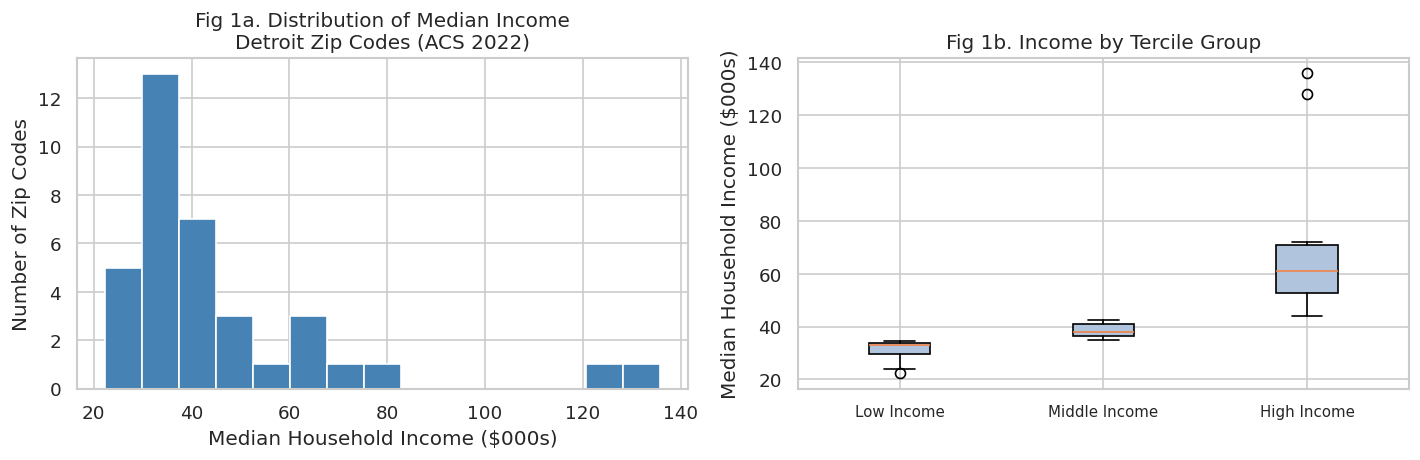

Saved: fig1_income_distribution.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1 = axes[0]
ax1.hist(acs_zip_detroit['median_income'].dropna() / 1000, bins=15, color='steelblue', edgecolor='white')
ax1.set_xlabel('Median Household Income ($000s)')
ax1.set_ylabel('Number of Zip Codes')
ax1.set_title('Fig 1a. Distribution of Median Income\nDetroit Zip Codes (ACS 2022)')

# Box plot by income group
ax2 = axes[1]
groups = ['Low Income', 'Middle Income', 'High Income']
data_by_group = [merged[merged['income_group']==g]['median_income'].dropna() / 1000 for g in groups]
bp = ax2.boxplot(data_by_group, labels=groups, patch_artist=True,
                  boxprops=dict(facecolor='lightsteelblue'))
ax2.set_ylabel('Median Household Income ($000s)')
ax2.set_title('Fig 1b. Income by Tercile Group')
ax2.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig1_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_income_distribution.png")

### Figure 2 — Top 311 Complaint Types by Income Group

This is the core Wang et al. replication: do complaint profiles differ systematically across income levels?

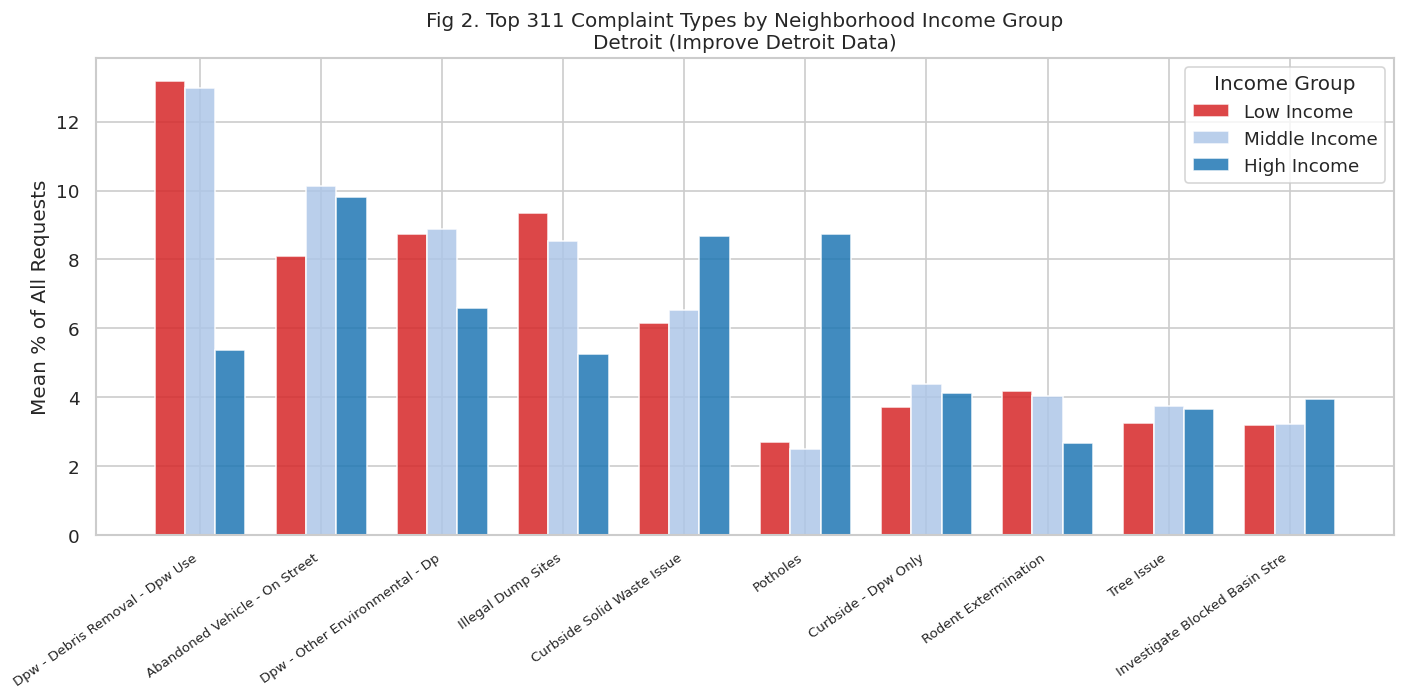

Saved: fig2_complaint_profiles.png


In [29]:
# Identify complaint type columns (exclude metadata cols)
meta_cols = ['median_income', 'pct_poverty', 'pct_unemployed',
             'pct_bachelors_plus', 'income_group', 'total_requests']
complaint_cols = [c for c in merged.columns if c not in meta_cols]

# Mean frequency per complaint type by income group
profile = merged.groupby('income_group')[complaint_cols].mean()

# Top 10 complaint types overall
top10 = profile.mean().sort_values(ascending=False).head(10).index.tolist()

profile_top10 = profile[top10].T  # complaints × income group

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10))
width = 0.25
colors = ['#d62728', '#aec7e8', '#1f77b4']

for i, (group, color) in enumerate(zip(['Low Income', 'Middle Income', 'High Income'], colors)):
    if group in profile_top10.columns:
        ax.bar(x + i * width, profile_top10[group] * 100, width, label=group, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([t[:30] for t in top10], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Mean % of All Requests')
ax.set_title('Fig 2. Top 311 Complaint Types by Neighborhood Income Group\nDetroit (Improve Detroit Data)')
ax.legend(title='Income Group')
plt.tight_layout()
plt.savefig('fig2_complaint_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_complaint_profiles.png")

### Figure 3 — 311 Request Volume vs. Poverty Rate

Tests whether reporting volume itself correlates with poverty (proxy for the underreporting bias Wang et al. and Rachael's project plan flag).

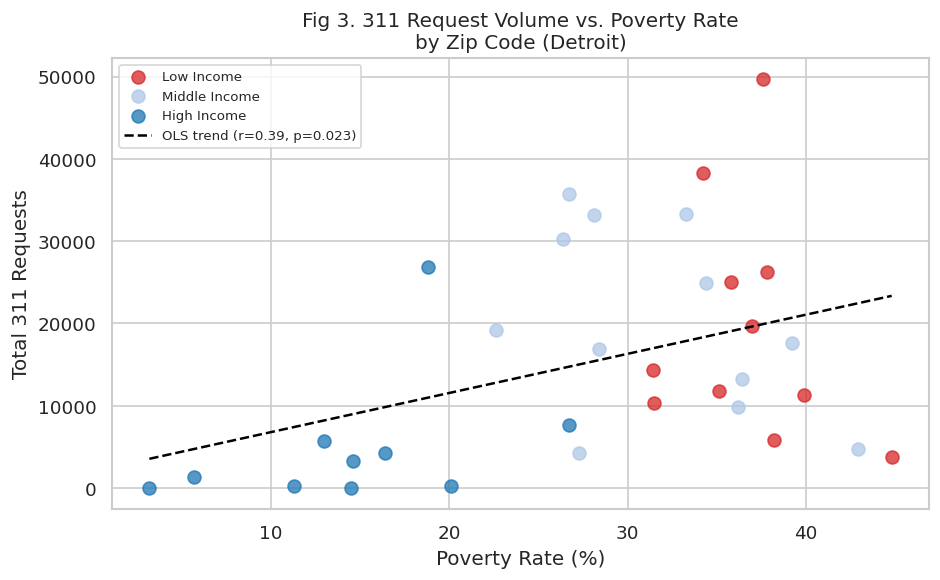

Correlation: r = 0.394, p = 0.0232
Saved: fig3_volume_vs_poverty.png


In [30]:
from scipy import stats

plot_df = merged[['pct_poverty', 'total_requests', 'income_group']].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

color_map = {'Low Income': '#d62728', 'Middle Income': '#aec7e8', 'High Income': '#1f77b4'}
for group, gdf in plot_df.groupby('income_group'):
    ax.scatter(gdf['pct_poverty'], gdf['total_requests'],
               color=color_map.get(str(group), 'gray'),
               label=str(group), alpha=0.75, s=60)

# OLS trend line
slope, intercept, r, p, _ = stats.linregress(plot_df['pct_poverty'], plot_df['total_requests'])
xs = np.linspace(plot_df['pct_poverty'].min(), plot_df['pct_poverty'].max(), 100)
ax.plot(xs, slope * xs + intercept, color='black', linewidth=1.5, linestyle='--',
        label=f'OLS trend (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Poverty Rate (%)')
ax.set_ylabel('Total 311 Requests')
ax.set_title('Fig 3. 311 Request Volume vs. Poverty Rate\nby Zip Code (Detroit)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig3_volume_vs_poverty.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation: r = {r:.3f}, p = {p:.4f}")
print("Saved: fig3_volume_vs_poverty.png")

### Table 1 — Descriptive Statistics by Income Group

In [31]:
summary_vars = ['median_income', 'pct_poverty', 'pct_unemployed', 'pct_bachelors_plus', 'total_requests']

table1 = merged.groupby('income_group')[summary_vars].agg(['mean', 'std']).round(1)
table1.columns = [
    'Median Income (mean)', 'Median Income (SD)',
    'Poverty Rate % (mean)', 'Poverty Rate % (SD)',
    'Unemployment % (mean)', 'Unemployment % (SD)',
    'Bachelor%+ (mean)', 'Bachelor%+ (SD)',
    'Total 311 Requests (mean)', 'Total 311 Requests (SD)'
]

print("Table 1. Descriptive Statistics by Income Tercile")
print("=" * 80)
display(table1.T)

Table 1. Descriptive Statistics by Income Tercile


income_group,Low Income,Middle Income,High Income
Median Income (mean),30839.3,38711.5,72432.8
Median Income (SD),4196.1,2688.0,32660.3
Poverty Rate % (mean),36.7,31.8,14.4
Poverty Rate % (SD),3.8,6.1,6.8
Unemployment % (mean),15.1,14.1,7.7
Unemployment % (SD),3.9,2.7,3.6
Bachelor%+ (mean),17.8,14.5,33.7
Bachelor%+ (SD),8.7,7.0,16.6
Total 311 Requests (mean),19697.7,20254.6,4970.2
Total 311 Requests (SD),14197.1,11187.8,8164.0


### Figure 4 (Bonus) — Complaint Profile Heatmap

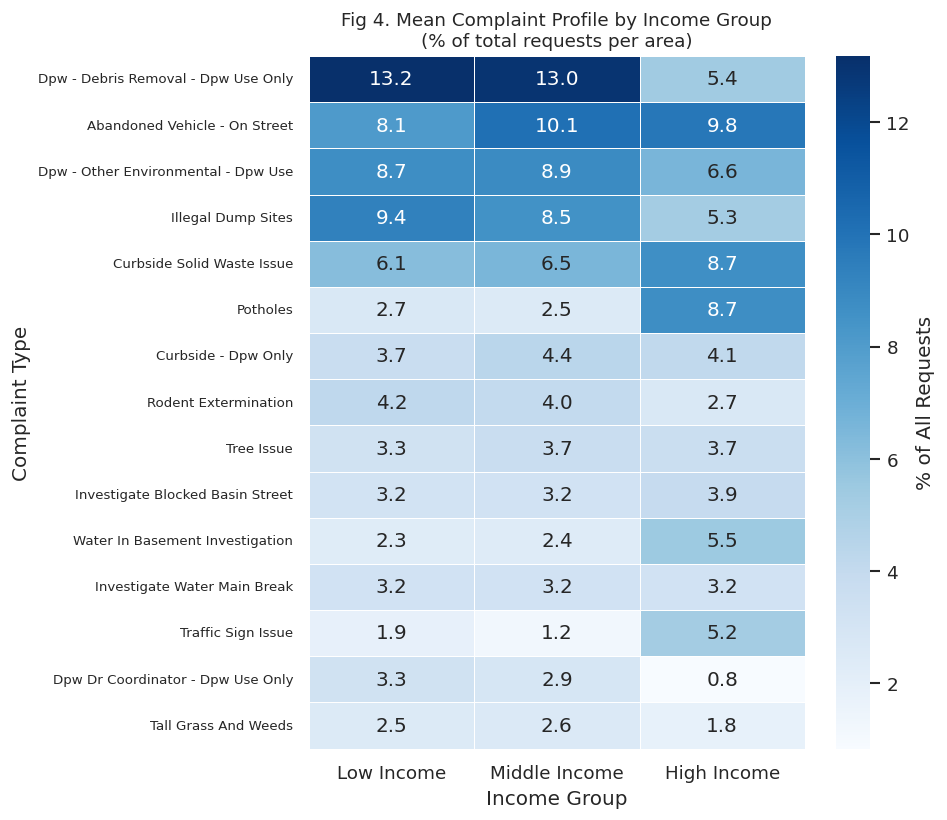

Saved: fig4_heatmap.png


In [32]:
# Heatmap: top 15 complaint types × income group
top15 = profile.mean().sort_values(ascending=False).head(15).index.tolist()
heat_data = profile[top15].T

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    heat_data * 100, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, ax=ax, cbar_kws={'label': '% of All Requests'}
)
ax.set_title('Fig 4. Mean Complaint Profile by Income Group\n(% of total requests per area)', fontsize=11)
ax.set_xlabel('Income Group')
ax.set_ylabel('Complaint Type')
ax.set_yticklabels([t[:35] for t in heat_data.index], fontsize=8)
plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_heatmap.png")

---
## 6. Interpretation & Write-Up Notes

Use this cell to write your observations as you go. Suggested structure:

**Finding 1 — Do complaint profiles differ by income group?**

> *[Fill in after running Fig 2. E.g.: Low-income zip codes show higher proportions of [X] complaints while high-income areas report more [Y], consistent with Wang et al.'s findings.]*

**Finding 2 — Is reporting volume correlated with poverty?**

> *[Fill in after running Fig 3 / Table 1. If r is negative, lower-income areas report fewer requests despite likely greater need — the underreporting bias Rachael's plan anticipates.]*

**Limitations**
- Using zip code rather than census tract reduces geographic precision.
- Sample-only download may miss seasonal patterns.
- Detroit's complaint categories differ from NYC/Boston/Chicago; direct comparison with Wang et al. is approximate.
- Underreporting is likely in disinvested neighborhoods (key finding to discuss!).

**Connection to Wang et al.**
- Wang et al. found R² ≈ 0.80 predicting housing prices from 311 clusters. This project focuses on the descriptive precursor: whether clusters are socioeconomically meaningful at all in Detroit's unique post-bankruptcy, historically redlined geography.

---
## 7. Export Clean Data for Reporting

In [33]:
# Save merged dataset
merged.to_csv('detroit_311_acs_merged.csv')
print("Saved: detroit_311_acs_merged.csv")

# Save complaint frequency profiles
profile.to_csv('complaint_profiles_by_income.csv')
print("Saved: complaint_profiles_by_income.csv")

# Save summary table
table1.T.to_csv('table1_descriptives.csv')
print("Saved: table1_descriptives.csv")

print("\nAll outputs ready for progress report submission.")

Saved: detroit_311_acs_merged.csv
Saved: complaint_profiles_by_income.csv
Saved: table1_descriptives.csv

All outputs ready for progress report submission.
